# Data analysis notebook

## Sample mode: load a subset of the data

In "full mode" (further below) I call the ChunkProcessor class to load the full dataset in chunks.

In [39]:
# Download sample data as df, set up Duck DB database

import duckdb

con = duckdb.connect()

df = con.execute("""
    SELECT *
    FROM read_csv_auto('/home/alan/alan_projects/data-project-templates/data-analysis/marketplace-analytics/data/2019-Oct.csv')
    ORDER BY user_id, event_time
    LIMIT 10
""").df()

con.close()

In [40]:
df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-23 20:04:08,view,7002639,2053013560346280633,kids.carriage,bumbleride,769.65,33869381,d83dc524-8a2c-4780-bbe0-f8aee03b54df
1,2019-10-13 00:13:46,view,10600284,2053013561554240247,NaN,NaN,0.00,64078358,6183edb9-f592-4bb8-9913-67bb4711694d
2,2019-10-02 21:43:00,view,22200103,2053013558785999453,NaN,NaN,15.77,183503497,884233e8-8b9f-4970-808b-4e1c81f8a5fc
3,2019-10-04 17:44:37,view,6902133,2053013560312726199,furniture.living_room.chair,joie,143.89,184265397,2c5d0468-32e1-42f7-9b4e-b17c1d387247
4,2019-10-04 17:45:18,view,6902133,2053013560312726199,furniture.living_room.chair,joie,143.89,184265397,2c5d0468-32e1-42f7-9b4e-b17c1d387247
5,2019-10-04 17:50:50,view,6902303,2053013560312726199,furniture.living_room.chair,joie,111.46,184265397,2c5d0468-32e1-42f7-9b4e-b17c1d387247
6,2019-10-04 17:51:04,view,6902303,2053013560312726199,furniture.living_room.chair,joie,111.46,184265397,2c5d0468-32e1-42f7-9b4e-b17c1d387247
7,2019-10-15 17:18:59,view,27400002,2053013563391345499,NaN,oral-b,79.77,184265397,c4ddb5b7-3185-453b-8e02-45d48a9775be
8,2019-10-15 17:19:28,view,27400002,2053013563391345499,NaN,oral-b,79.77,184265397,c4ddb5b7-3185-453b-8e02-45d48a9775be
9,2019-10-10 03:35:36,view,4804056,2053013554658804075,electronics.audio.headphone,apple,161.88,195082191,ad2e4ed4-26d4-45bc-b8ff-ee55ac1765cc


In [44]:
# Connect to duck db on a new database (create new db file at connection)
con = duckdb.connect("/home/alan/alan_projects/data-project-templates/data-analysis/marketplace-analytics/data/marketplace-analytics.duckdb")

# Create dbt schemas for this exercise
con.execute("CREATE SCHEMA raw")
con.execute("CREATE SCHEMA staging")
con.execute("CREATE SCHEMA marts")

# Create base sample table from downloaded df. It will be ingested and transformed within the dbt framework
con.execute("""
            CREATE TABLE IF NOT EXISTS raw.events AS 
            --CREATE OR REPLACE TABLE raw.events AS 
            SELECT * FROM df
            LIMIT 1000000
            """)

In [45]:
# To delete later
con.execute("SELECT COUNT(*) FROM raw.events").fetchall()
con.execute("DROP TABLE IF EXISTS main.events")
con.execute("SHOW schemas").fetchall()
con.sql("SHOW tables from raw").show()
con.sql("""
        WITH base AS (
        SELECT user_id FROM staging.stg_events GROUP BY 1 HAVING count(distinct event_name) > 1
        )
        SELECT s.user_id, array_agg(distinct event_type) FROM staging.stg_events s JOIN base b ON s.user_id = b.user_id GROUP BY 1 LIMIT 5 
""")

[(1000000,)]

## Full mode: load full dataset

Call the ChunkProcessor class to break down the large csv files into smaller parquet files, which then are loaded into the db, much faster than the full csv files would (and also well within RAM for most home computers).

In [6]:
# Add root dir to Python path
import sys
import os

project_root = os.path.abspath("../")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [ ]:
# Connect to duck db on a new database (create new db file at connection)
con = duckdb.connect("/home/alan/alan_projects/data-project-templates/data-analysis/marketplace-analytics/data/marketplace-analytics.duckdb")

# Create dbt schemas for this exercise
con.execute("CREATE SCHEMA raw")
con.execute("CREATE SCHEMA staging")
con.execute("CREATE SCHEMA marts")

In [17]:
from utils.chunk_processor import ChunkProcessor

processor = ChunkProcessor(chunk_size=10000000)

# Ingestion and load to db (run full cycle for each source csv file, otherwise new parquet chunk will overwrite older ones before db load)
# TODO: Idempotency: right now the db upload is a simple insert, if you run it twice, it duplicates data
filenames = ['2019-Oct', '2019-Nov']
for file in filenames:
    csv_path = f'/home/alan/alan_projects/data-project-templates/data-analysis/marketplace-analytics/data/{file}.csv'
    output_dir = f'/home/alan/alan_projects/data-project-templates/data-analysis/marketplace-analytics/data/chunks_{file}'
    #chunks = processor.chunk_csv_to_parquet(input_csv_path=csv_path, output_dir=output_dir)

    db_path = '/home/alan/alan_projects/data-project-templates/data-analysis/marketplace-analytics/data/marketplace-analytics.duckdb'
    #processor.load_chunks_to_duckdb(chunks, db_path=db_path)

Wrote /home/alan/alan_projects/data-project-templates/data-analysis/marketplace-analytics/data/chunks_oct/chunk_000.parquet (10,000,000 rows)
Wrote /home/alan/alan_projects/data-project-templates/data-analysis/marketplace-analytics/data/chunks_oct/chunk_001.parquet (10,000,000 rows)
Wrote /home/alan/alan_projects/data-project-templates/data-analysis/marketplace-analytics/data/chunks_oct/chunk_002.parquet (10,000,000 rows)
Wrote /home/alan/alan_projects/data-project-templates/data-analysis/marketplace-analytics/data/chunks_oct/chunk_003.parquet (10,000,000 rows)
Wrote /home/alan/alan_projects/data-project-templates/data-analysis/marketplace-analytics/data/chunks_oct/chunk_004.parquet (2,448,764 rows)
Done: 5 chunks created


## Run A/B test

In [30]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.stats.proportion import proportions_ztest

In [31]:
# Get data from duck DB
con = duckdb.connect("/home/alan/alan_projects/data-project-templates/data-analysis/marketplace-analytics/data/marketplace-analytics.duckdb")

query_user = "SELECT * FROM marts.fct_ab_test_user"
query_session = "SELECT * FROM marts.fct_ab_test_session"

df_ab_user = con.execute(query_user).df()
print("AB test metrics - User level: \n", df_ab_user.head(), "\n")

df_ab_session = con.execute(query_session).df()
print("AB test metrics - Session level: \n", df_ab_session.head())

# Always close at the end of every routine
con.close()

AB test metrics - User level: 
   variant_user    users  conversions  user_conversion_rate  \
0            A  2657088     347935.0              0.130946   
1            B  2659561     349535.0              0.131426   

   view_conversion_rate  
0              0.130959  
1              0.131438   

AB test metrics - Session level: 
   variant_session  user_sessions  conversions  session_conversion_rate  \
0               B       11512653     701047.0                 0.060894   
1               A       11503997     701711.0                 0.060997   

   view_conversion_rate  
0              0.060923  
1              0.061026  


In [32]:
# Get A/B metrics, summarize them, run z-test

metrics = {}

# Map each metric name to its respective DataFrame
datasets = {
    "users": df_ab_user.set_index('variant_user'),
    "sessions": df_ab_session.set_index('variant_session')
}

for name, df in datasets.items():
    # Quick sense check: summarize relevant metrics
    if name == 'users':
        cr_A = df.loc['A', 'user_conversion_rate']
        cr_B = df.loc['B', 'user_conversion_rate']
    else:
        cr_A = df.loc['A', 'session_conversion_rate']
        cr_B = df.loc['B', 'session_conversion_rate']
    
    uplift = (cr_B / cr_A) - 1

    col_name = 'Users' if name == 'users' else 'Sessions'
    data_col = 'users' if name == 'users' else 'user_sessions'
    summary = pd.DataFrame({
        'Variant': ['A (Control)', 'B (Treatment)'],
        col_name: [df.loc['A', data_col], df.loc['B', data_col]],
        'Conversions': [df.loc['A', 'conversions'], df.loc['B', 'conversions']],
        'Conversion Rate': [f"{cr_A:.3%}", f"{cr_B:.3%}"],
        'Uplift': uplift,
    })
    
    print(f"\nSummary table - {name} level:")
    print(summary)


    # Run z-test
    success = [df.loc['A', 'conversions'], df.loc['B', 'conversions']]
    nobs = [df.loc['A', 'users'], df.loc['B', 'users']] if name == 'users' else [df.loc['A', 'user_sessions'], df.loc['B', 'user_sessions']]

    z_stat, p_value = proportions_ztest(success, nobs)

    print(f"\nStatistical test - {name} level:")
    print(f"Absolute difference: {(cr_B - cr_A)*100:.2} p.p.")
    print(f"Relative uplift: {uplift*100:.2f}%")
    print(f"p-value: {p_value:.4f}")

    alpha = 0.01

    if p_value < alpha:
        print("Result: Statistically significant at α=0.05")
    else:
        print("Result: Not statistically significant at α=0.05 (expected in simulated setup)")


Summary table - users level:
         Variant    Users  Conversions Conversion Rate    Uplift
0    A (Control)  2657088     347935.0         13.095%  0.003664
1  B (Treatment)  2659561     349535.0         13.143%  0.003664

Statistical test - users level:
Absolute difference: 0.048 p.p.
Relative uplift: 0.37%
p-value: 0.1013
Result: Not statistically significant at α=0.05 (expected in simulated setup)

Summary table - sessions level:
         Variant  Sessions  Conversions Conversion Rate    Uplift
0    A (Control)  11503997     701711.0          6.100% -0.001697
1  B (Treatment)  11512653     701047.0          6.089% -0.001697

Statistical test - sessions level:
Absolute difference: -0.01 p.p.
Relative uplift: -0.17%
p-value: 0.2992
Result: Not statistically significant at α=0.05 (expected in simulated setup)


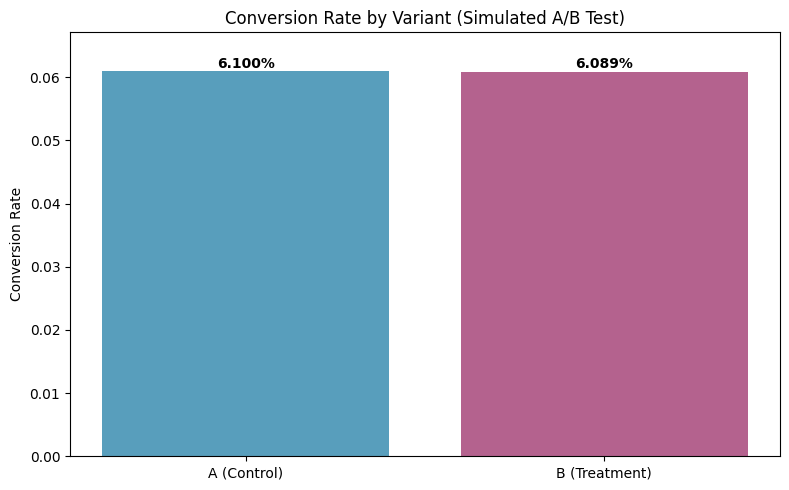

In [33]:
# Example chart: conversion rate by variant

plt.figure(figsize=(8, 5)) 
plt.bar(['A (Control)', 'B (Treatment)'], [cr_A, cr_B], 
        color=['#2E86AB', '#A23B72'], alpha=0.8)
plt.ylabel('Conversion Rate')
plt.title('Conversion Rate by Variant (Simulated A/B Test)')
plt.ylim(0, max(cr_A, cr_B) * 1.1) 
for i, v in enumerate([cr_A, cr_B]):
    plt.text(i, v + 0.0005, f'{v:.3%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Extras

## Funnel chart

In [35]:
con = duckdb.connect("../data/marketplace-analytics.duckdb")


Couple examples of sessions that skipped add to cart:
00213f22-62b4-4092-ab98-317a9a372167
005225f3-e843-4bee-93eb-3aef9b8b0c65

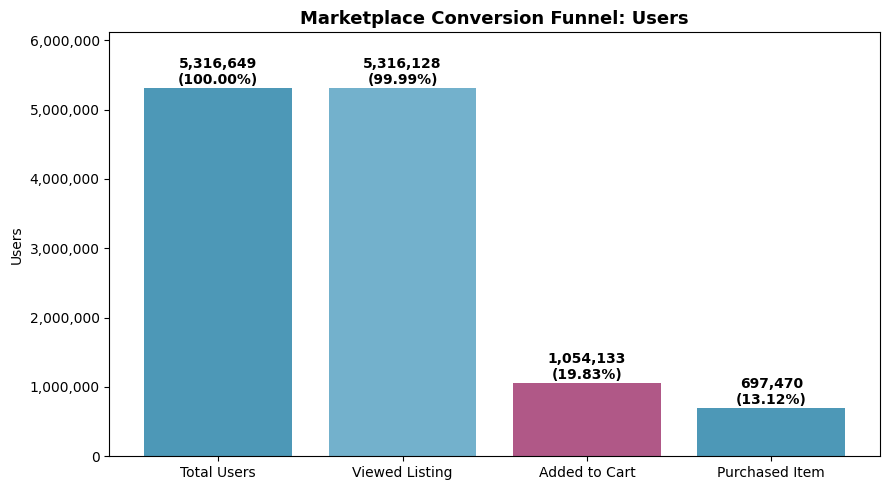

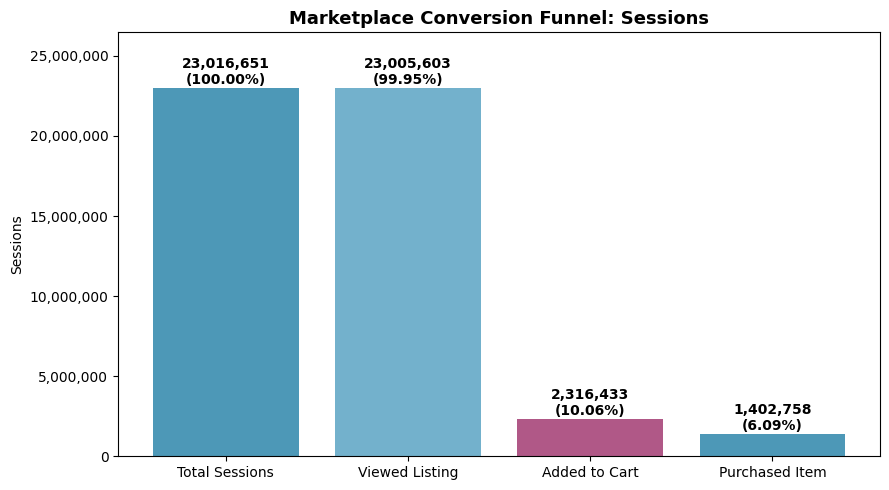

In [36]:
# === FUNNEL ANALYSIS ===


agg_level = ['user', 'session']

for level in agg_level:
    #con = duckdb.connect("../data/marketplace-analytics.duckdb")
    df_funnel = con.execute(f"SELECT * FROM marts.fct_funnel_{level}").df()
    #con.close()


    col_name = 'Users' if level == 'user' else 'Sessions'
    funnel_steps = {
        f'Total {col_name}':      len(df_funnel), 
        'Viewed Listing':   df_funnel['viewed'].sum(),
        'Added to Cart':    df_funnel['added_to_cart'].sum(),
        'Purchased Item': df_funnel['purchased'].sum()
    }


    steps = list(funnel_steps.keys())
    agg_ids = list(funnel_steps.values())
    drop_off = [1.0] + [agg_ids[i] / agg_ids[0] for i in range(1, len(agg_ids))]

    # Chart
    fig, ax = plt.subplots(figsize=(9, 5))

    bars = ax.bar(steps, agg_ids, color=['#2E86AB', '#5BA4C4', '#A23B72'], alpha=0.85)

    # Value labels on bars
    for bar, u, pct in zip(bars, agg_ids, drop_off):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(agg_ids) * 0.01,
                f'{int(u):,}\n({pct:.2%})',
                ha='center', fontsize=10, fontweight='bold')

    ax.set_ylabel(f'{col_name}')
    ax.set_title(f'Marketplace Conversion Funnel: {col_name}', fontsize=13, fontweight='bold')
    ax.set_ylim(0, max(agg_ids) * 1.15)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

    plt.tight_layout()
    plt.savefig(f'../data/funnel_chart_{level}.png', dpi=150)
    plt.show()


## Segment conversion analysis

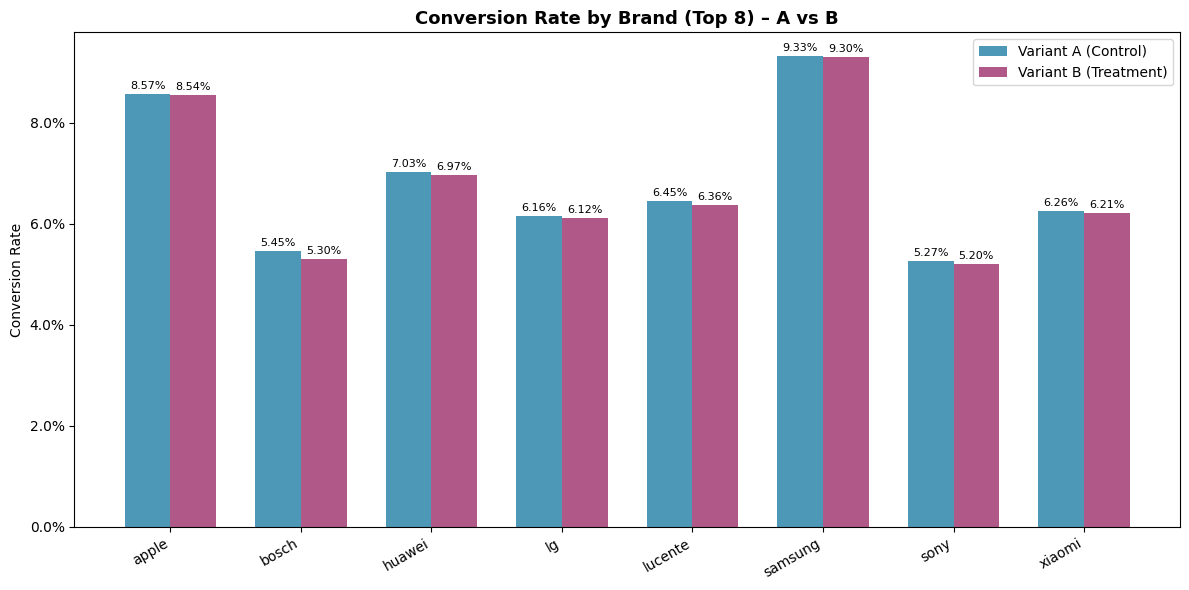

In [37]:
# === SEGMENTED A/B ANALYSIS ===
con = duckdb.connect("../data/marketplace-analytics.duckdb")

# Run dbt segment view first (or query directly)
# If you want to query the DB directly and get the results in a dataframe as in a view (easier, but not production grade)
'''
df_segment = con.execute("""
    SELECT
        s.brand AS segment,
        f.variant,
        COUNT(DISTINCT f.user_id) AS users,
        SUM(f.purchased) AS conversions,
        SUM(f.purchased) * 1.0 / COUNT(DISTINCT f.user_id) AS conversion_rate
    FROM marts.fct_funnel f
    JOIN marts.segments s ON f.user_id = s.user_id
    WHERE s.brand IS NOT NULL
    GROUP BY 1, 2
    ORDER BY 3 DESC
""").df()
con.close()
'''

# A more robust approach is to create views in the dbt project using the view macro; these views persist, and you can load them as a df as well

# Run from terminal first: 
# dbt run --select fct_ab_brand

# Then you can query the view as a data artifact from Duck DB 
df_segment = con.execute("SELECT * FROM marts.fct_ab_brand_session").df()

# Top N brands only (avoid chart clutter)
TOP_N = 8
top_brands = (
    df_segment.groupby('segment')['user_sessions']
    .sum()
    .nlargest(TOP_N)
    .index
)
df_plot = df_segment[df_segment['segment'].isin(top_brands)]

# Pivot for side-by-side bars
df_pivot = df_plot.pivot(index='segment', columns='variant_session', values='conversion_rate')

# Chart
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(df_pivot))
width = 0.35

bars_A = ax.bar([i - width/2 for i in x], df_pivot['A'], width,
                label='Variant A (Control)', color='#2E86AB', alpha=0.85)
bars_B = ax.bar([i + width/2 for i in x], df_pivot['B'], width,
                label='Variant B (Treatment)', color='#A23B72', alpha=0.85)

# Value labels
for bar in bars_A:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f'{bar.get_height():.2%}',
            ha='center', fontsize=8)

for bar in bars_B:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f'{bar.get_height():.2%}',
            ha='center', fontsize=8)

ax.set_xticks(list(x))
ax.set_xticklabels(df_pivot.index, rotation=30, ha='right')
ax.set_ylabel('Conversion Rate')
ax.set_title(f'Conversion Rate by Brand (Top {TOP_N}) – A vs B', fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1%}'))

plt.tight_layout()
plt.savefig('../data/segment_chart.png', dpi=150)
plt.show()


## Re-engagement analysis

  variant_user  converters  returned  return_rate
0            B      349535  311001.0     0.889756
1            A      347935  309689.0     0.890077


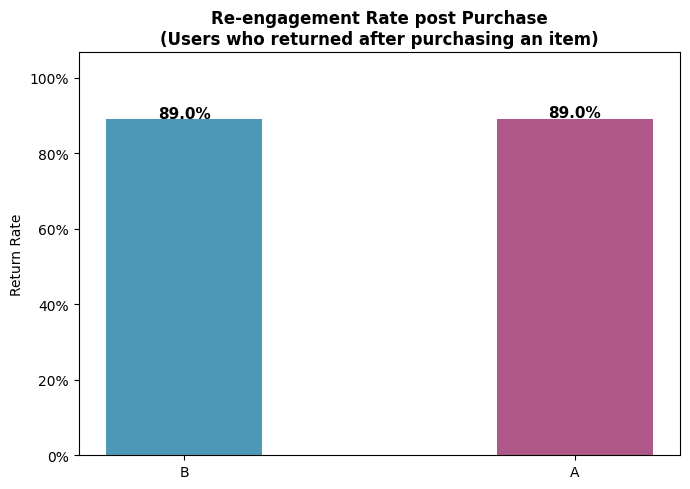

In [38]:
# === RE-ENGAGEMENT ANALYSIS ===
con = duckdb.connect("/home/alan/alan_projects/data-project-templates/data-analysis/marketplace-analytics/data/marketplace-analytics.duckdb")

df_reengagement = con.execute("""
    WITH converters AS (
        -- Users who purchased an item
        SELECT DISTINCT
            f.user_id,
            f.variant_user,
            MIN(e.event_time) AS first_purchase_time
        FROM marts.fct_funnel_user f
        JOIN staging.stg_events e 
            ON f.user_id = e.user_id 
            AND e.event_name = 'purchase_item'
        WHERE f.purchased = 1
        GROUP BY 1, 2
    ),
    return_events AS (
        -- Did they come back after first purchase?
        SELECT
            c.user_id,
            c.variant_user,
            COUNT(e.event_type) AS events_after_purchase
        FROM converters c
        LEFT JOIN staging.stg_events e
            ON c.user_id = e.user_id
            AND e.event_time > c.first_purchase_time
        GROUP BY 1, 2
    )
    SELECT
        variant_user,
        COUNT(DISTINCT user_id)                                          AS converters,
        SUM(CASE WHEN events_after_purchase > 0 THEN 1 ELSE 0 END)       AS returned,
        SUM(CASE WHEN events_after_purchase > 0 THEN 1 ELSE 0 END) * 1.0
            / COUNT(DISTINCT user_id)                                    AS return_rate
    FROM return_events
    GROUP BY 1
""").df()
con.close()

print(df_reengagement)

# Chart
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    df_reengagement['variant_user'],
    df_reengagement['return_rate'],
    color=['#2E86AB', '#A23B72'],
    alpha=0.85,
    width=0.4
)

for bar, rate in zip(bars, df_reengagement['return_rate']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{rate:.1%}',
            ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Return Rate')
ax.set_title('Re-engagement Rate post Purchase\n(Users who returned after purchasing an item)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(df_reengagement['return_rate']) * 1.2)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

plt.tight_layout()
plt.savefig('../data/reengagement_chart.png', dpi=150)
plt.show()
